In [6]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 4.977 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.4    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [28]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.998 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.6.17  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.4.9      pyhd8ed1ab_0         conda-forge
+ idna                3.18       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.24.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools        

In [33]:
!mamba install statsmodels

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, statsmodels
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 10.367 seconds
  Name         Version  Build                Channel
------------------------------------------------------------------
+ patsy        1.0.2    py313h1804a44_3      emscripten-forge-4x
+ statsmodels  0.14.6   np23py313hd8db738_2  emscripten-forge-4x


In [9]:
pip install seaborn

mambajs 0.21.4

Process pip requirements ...

Requirement numpy already satisfied.
Requirement pandas already satisfied.
Requirement matplotlib already satisfied.


In [10]:
# Supress Warnings

import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package

import numpy as np
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
advertising = pd.DataFrame(pd.read_csv("advertising.csv"))
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [11]:
advertising.shape

(200, 4)

In [12]:
advertising.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.3 KB


In [13]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [14]:
# Checking Null values
advertising.isnull().sum()*100/advertising.shape[0]
# There are no NULL values in the dataset, hence it is clean.

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

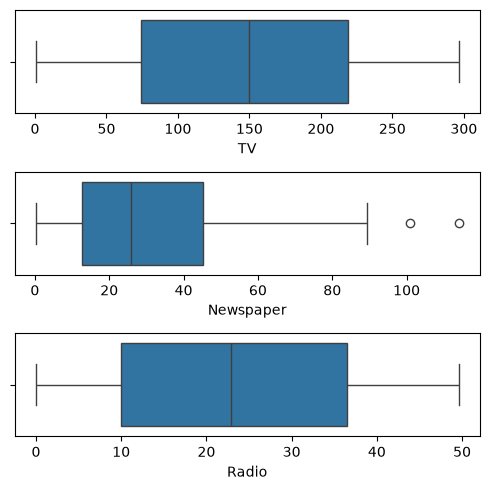

In [21]:
# Outlier Analysis
fig, axs = plt.subplots(3, figsize = (5,5))
plt1 = sns.boxplot(x=advertising['TV'], ax = axs[0]) 
plt2 = sns.boxplot(x=advertising['Newspaper'], ax = axs[1])
plt3 = sns.boxplot(x=advertising['Radio'], ax = axs[2])
plt.tight_layout()


In [48]:
#No significant outliers are observed in the dataset.

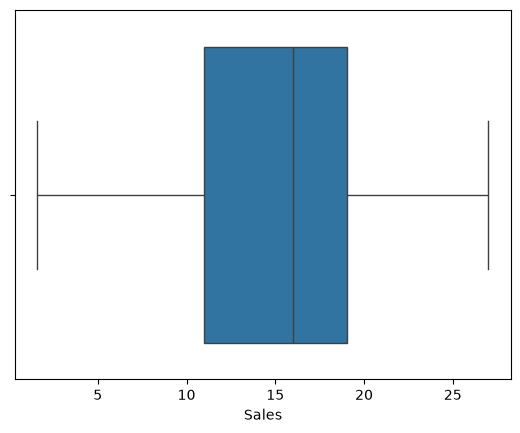

In [23]:
sns.boxplot(x=advertising['Sales'])
plt.show()

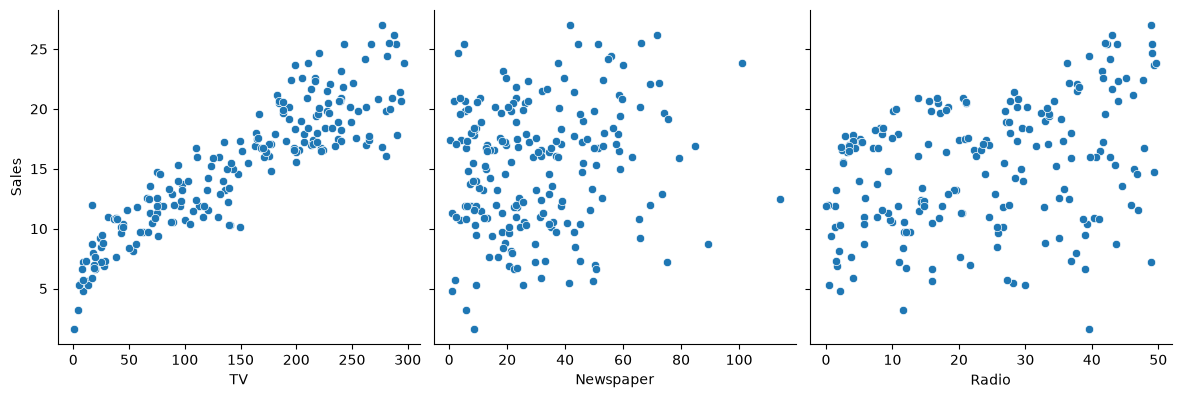

In [24]:
# Let's see how Sales are related with other variables using scatter plot.
sns.pairplot(advertising, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.show()

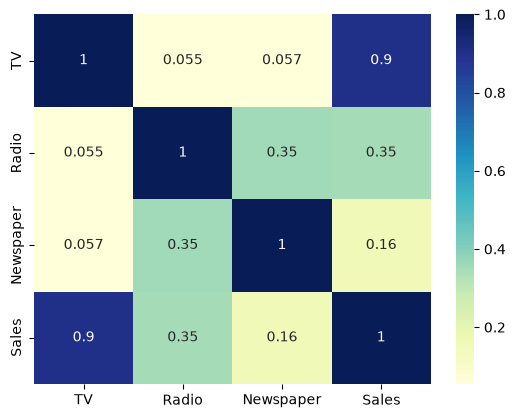

In [25]:
# Let's see the correlation between different variables.
sns.heatmap(advertising.corr(), cmap="YlGnBu", annot = True)
plt.show()

In [26]:
X = advertising['TV']
y = advertising['Sales']

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [30]:
# Let's now take a look at the train dataset

X_train.head()

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
Name: TV, dtype: float64

In [31]:
y_train.head()

74     17.0
3      16.5
185    22.6
26     15.0
90     14.0
Name: Sales, dtype: float64

In [34]:
import statsmodels.api as sm

In [35]:
# Add a constant to get an intercept
X_train_sm = sm.add_constant(X_train)

# Fit the resgression line using 'OLS'
lr = sm.OLS(y_train, X_train_sm).fit()

In [36]:
# Print the parameters, i.e. the intercept and the slope of the regression line fitted
lr.params

const    6.948683
TV       0.054546
dtype: float64

In [37]:
# Performing a summary operation lists out all the different parameters of the regression line fitted
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Tue, 14 Jul 2026   Prob (F-statistic):           1.52e-52
Time:                        20:56:43   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.0

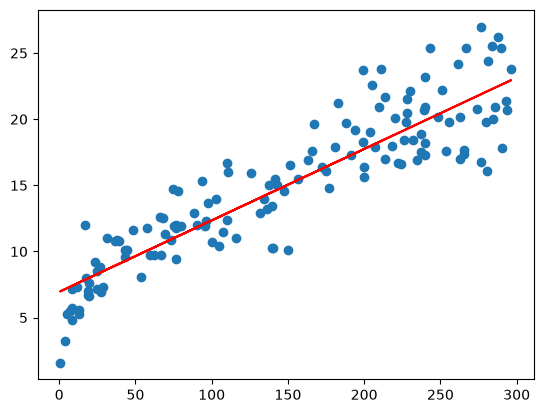

In [38]:
plt.scatter(X_train, y_train)
plt.plot(X_train, 6.948 + 0.054*X_train, 'r')
plt.show()

In [39]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

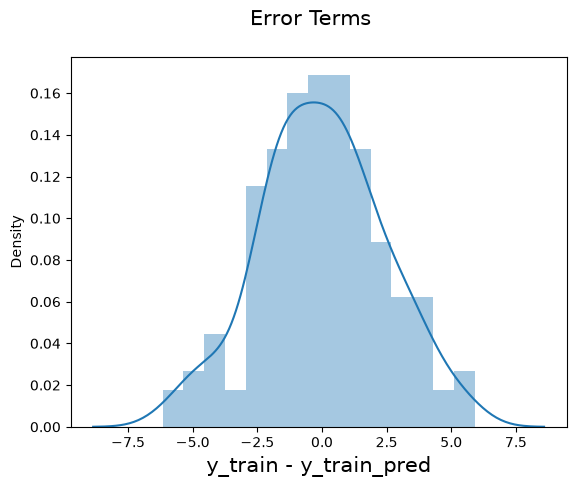

In [40]:
fig = plt.figure()
sns.distplot(res, bins = 15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading 
plt.xlabel('y_train - y_train_pred', fontsize = 15)         # X-label
plt.show()

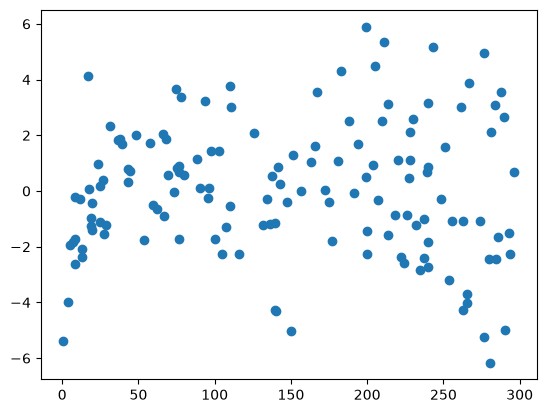

In [41]:
plt.scatter(X_train,res)
plt.show()

In [42]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_sm
y_pred = lr.predict(X_test_sm)

In [43]:
y_pred.head()

126     7.374140
104    19.941482
99     14.323269
92     18.823294
111    20.132392
dtype: float64

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [50]:
#Returns the mean squared error; we'll take a square root
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(2.0192960089662324)

In [46]:
r_squared = r2_score(y_test, y_pred)
r_squared

0.7921031601245659

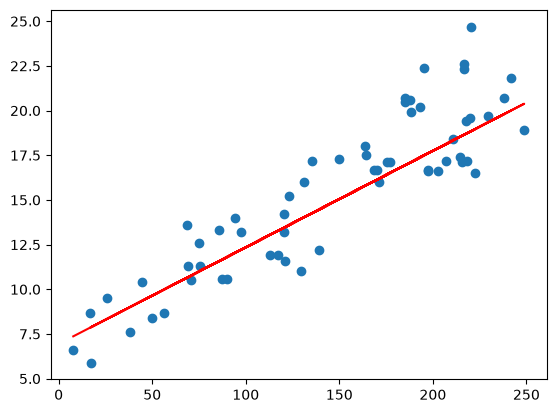

In [47]:
plt.scatter(X_test, y_test)
plt.plot(X_test, 6.948 + 0.054 * X_test, 'r')
plt.show()